# Untuned neuron analysis


See plots for one model in 1_singleneurons/1_firing_patterns/plot_rates_badv2.ipynb


Question: How are the tuning-based subpopulations contributing to memory maintenance differently?
- here, we investigate untuned neurons


In [1]:
import numpy as np 
import sys
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import scipy
import os
import importlib
import pandas as pd

sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
import load_data as ld 
import single_neuron_utils as sn 
import bhv_utils as bhv
from bootstrap_method import *



2025-05-15 15:16:58.427975: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 15:16:58.436079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-15 15:16:58.444938: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-15 15:16:58.447561: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-15 15:16:58.454780: I tensorflow/core/platform/cpu_feature_guar

## Get bad models

In [2]:
delay = 150
condn_phrase = 'delay'
condn_num = delay

# find folder names within model directory
all_models_dir = '/home/nuttidalab/Documents/renee/all_DMS_models/'
model_dirs = ld.get_immediate_subdirs(all_models_dir)

bad_models = []
for model_name in model_dirs:
    # get model directory
    model_dir = os.path.join(all_models_dir, model_name)
    
    _, trial_perfs = ld.load_bhv_data(model_name, condn_phrase, condn_num)
    if np.mean(trial_perfs) > 0.6 and np.mean(trial_perfs) < 0.8:
        bad_models.append(model_name)
        print(f'{model_name} has performance {np.mean(trial_perfs)}, bad model # {len(bad_models)}')

Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_084645 has performance 0.679, bad model # 1
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_163926 has performance 0.781, bad model # 2
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_160648 has performance 0.683, bad model # 3
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_234449 has performance 0.644, bad model # 4
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_040139 has performance 0.654, bad model # 5
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_032959 has performance 0.782, bad model # 6
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_11_06_080217 has performance 0.763, bad model # 7
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_191643 has performance 0.648, bad model # 8
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906 has performance 0.743, bad model # 9
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_07_004449 has performance 0.757, bad model # 10
Task_xor_N_200_Taus_4.0_25.0_Act_sigmoi

## Loop thru bad models

In [8]:
def plot_presyn_connections(ax, untuned_connectivity, untuned_idxs):
    for n_neuron, neuron_idx in enumerate(untuned_idxs):
        # get the number of presynaptic connections for this neuron
        presyn_df = untuned_connectivity[untuned_connectivity['postsyn_id'] == neuron_idx]
        # get the number of presynaptic connections for this neuron
        n_inh = np.sum(presyn_df['presyn_type'] == 'inh')
        n_exc = np.sum(presyn_df['presyn_type'] == 'exc')
        num_presyn = len(untuned_connectivity[untuned_connectivity['postsyn_id'] == neuron_idx])
        if n_inh + n_exc != num_presyn:
            print(f'Neuron {neuron_idx} has {num_presyn} presynaptic connections, but {n_inh} inh and {n_exc} exc')
        
        # plot the number of presynaptic connections for this neuron
        if n_inh > 0:
            ax.bar(n_neuron, n_inh, color='blue', alpha=0.5)
        if n_exc > 0:
            ax.bar(n_neuron, n_exc, bottom=n_inh, color='red', alpha=0.5)

    # set the x ticks to be the neuron indices
    ax.set_xticks(np.arange(len(untuned_idxs)))
    ax.set_xticklabels(untuned_idxs, rotation=90)
    # set the x label
    ax.set_xlabel('Neuron index')
    # set the y label
    ax.set_ylabel('Number of presynaptic connections')
    # set the title
    ax.set_title('Number of presynaptic connections for each untuned neuron')

In [5]:
def get_num_presyn(connectivity_df, neuron_idxs):
    # get the connectivity of the neurons of interest
    connectivity = connectivity_df[connectivity_df['postsyn_id'].isin(neuron_idxs)]
    # sort the connectivity by the postsynaptic neuron
    connectivity = connectivity.sort_values(by='postsyn_id')
    # get the number of presynaptic connections per neuron
    num_presyn = connectivity['postsyn_id'].value_counts()

    # if some neuron idxs weren't included, add them as rows of zeros
    for neuron_idx in neuron_idxs:
        if neuron_idx not in num_presyn.index:
            num_presyn[neuron_idx] = 0
    # sort the index
    num_presyn = num_presyn.sort_index()

    return num_presyn

In [17]:
def plot_violin_presynaptic(ax, untuned_connectivity, untuned_idxs, exc_ind, inh_ind):
    # get the number of presynaptic connections per neuron for each category
    exc_num_presyn = get_num_presyn(connectivity_df, exc_ind)
    exc_ind_tuned = np.setdiff1d(exc_ind, untuned_idxs) # exclude the exc neurons that are also untuned
    exc_tuned_num_presyn = get_num_presyn(connectivity_df, exc_ind_tuned) # exclude the exc neurons that are also untuned
    inh_num_presyn = get_num_presyn(connectivity_df, inh_ind)
    inh_ind_tuned = np.setdiff1d(inh_ind, untuned_idxs) # exclude the inh neurons that are also untuned
    inh_tuned_num_presyn = get_num_presyn(connectivity_df, inh_ind_tuned) # exclude the inh neurons that are also untuned
    # get the number of presynaptic connections per neuron for the untuned neurons
    untuned_num_presyn = get_num_presyn(connectivity_df, untuned_idxs)
    # get the number of presynaptic connections per neuron for all neurons
    all_num_presyn = get_num_presyn(connectivity_df, np.arange(0, len(exc_ind) + len(inh_ind)))

    # ax.violinplot([exc_tuned_num_presyn, inh_tuned_num_presyn, untuned_num_presyn, all_num_presyn], showmeans=True)
    ax.violinplot([exc_tuned_num_presyn, inh_tuned_num_presyn, untuned_num_presyn], showmeans=True)
    # plot scatter points
    ax.scatter(np.random.normal(1, 0.1, size=len(exc_tuned_num_presyn)), exc_tuned_num_presyn, color='r', alpha=0.5)
    ax.scatter(np.random.normal(2, 0.1, size=len(inh_tuned_num_presyn)), inh_tuned_num_presyn, color='b', alpha=0.5)
    ax.scatter(np.random.normal(3, 0.1, size=len(untuned_num_presyn)), untuned_num_presyn, color='g', alpha=0.5)
    # ax.scatter(np.random.normal(4, 0.1, size=len(all_num_presyn)), all_num_presyn, color='k', alpha=0.5)
    ax.set_ylabel('Number of presynaptic connections')
    ax.set_xlabel('Neuron type')
    # ax.set_xticks([1, 2, 3, 4])
    # ax.set_xticklabels(['exc, tuned', 'inh, tuned', 'untuned', 'all'])
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['exc, tuned', 'inh, tuned', 'untuned'])
    ax.set_title('Number of presynaptic connections per neuron type')

    # stats on this
    # exc_inh_p = scipy.stats.mannwhitneyu(exc_num_presyn, inh_num_presyn, alternative='two-sided')[1]
    exc_inh_tuned_p = scipy.stats.mannwhitneyu(exc_tuned_num_presyn, inh_tuned_num_presyn, alternative='two-sided')[1]
    exc_untuned_p = scipy.stats.mannwhitneyu(exc_tuned_num_presyn, untuned_num_presyn, alternative='two-sided')[1]
    inh_untuned_p = scipy.stats.mannwhitneyu(inh_tuned_num_presyn, untuned_num_presyn, alternative='two-sided')[1]

    # plot * and p-value for p < 0.05
    max_val = np.amax(all_num_presyn)
    if exc_inh_tuned_p < 0.05:
        ax.text(1.5, max_val+1, '*', fontsize=20, ha='center', va='center')
        ax.text(1.5, max_val+1, f'p = {exc_inh_tuned_p:.3f}', fontsize=10, ha='center', va='center')
        ax.plot([1, 2], [max_val+1, max_val+1], color='k', lw=1)
    if exc_untuned_p < 0.05:
        ax.text(2, max_val+2, '*', fontsize=20, ha='center', va='center')
        ax.text(2, max_val+2, f'p = {exc_untuned_p:.3f}', fontsize=10, ha='center', va='center')
        ax.plot([1, 3], [max_val+2, max_val+2], color='k', lw=1)
    if inh_untuned_p < 0.05:
        ax.text(2.5, max_val+3, '*', fontsize=20, ha='center', va='center')
        ax.text(2.5, max_val+3, f'p = {inh_untuned_p:.3f}', fontsize=10, ha='center', va='center')
        ax.plot([2, 3], [max_val+3, max_val+3], color='k', lw=1)
    # if exc_inh_p < 0.05:



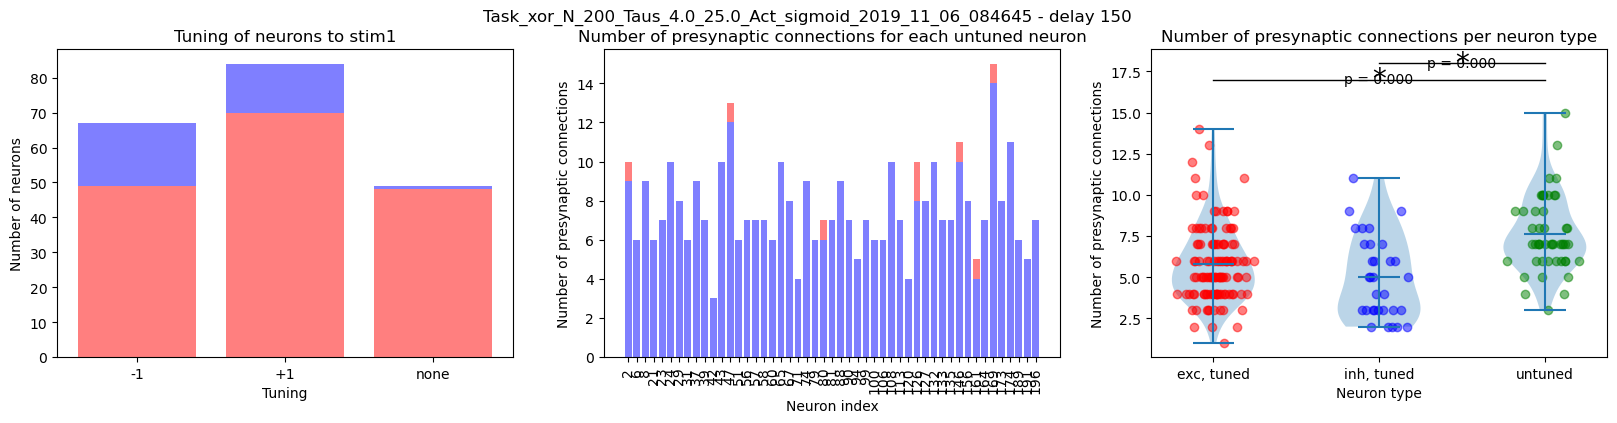

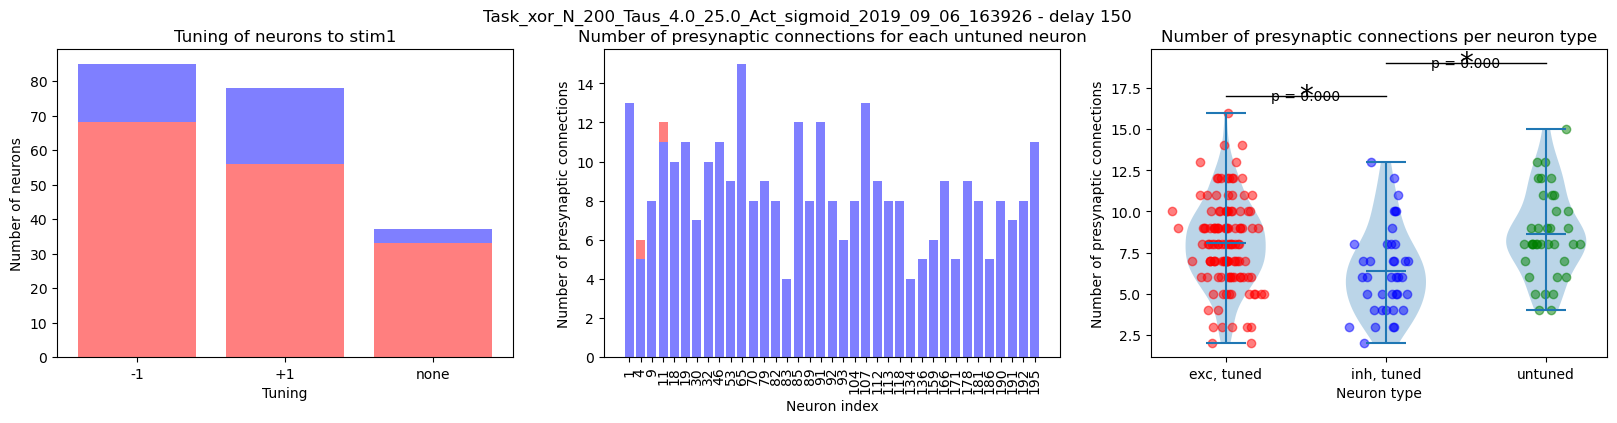

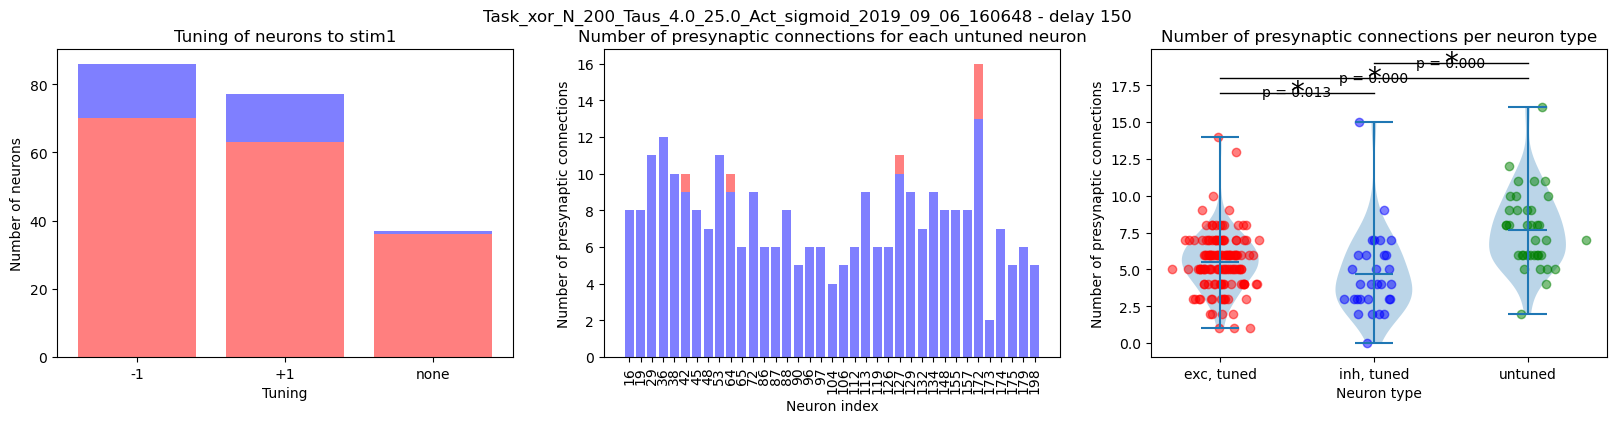

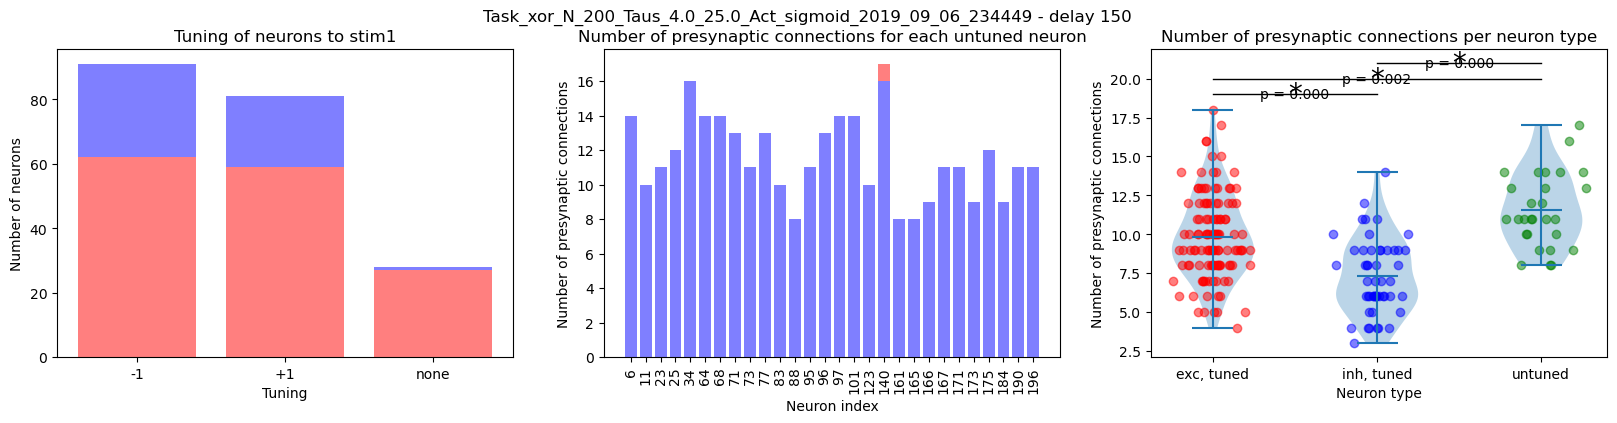

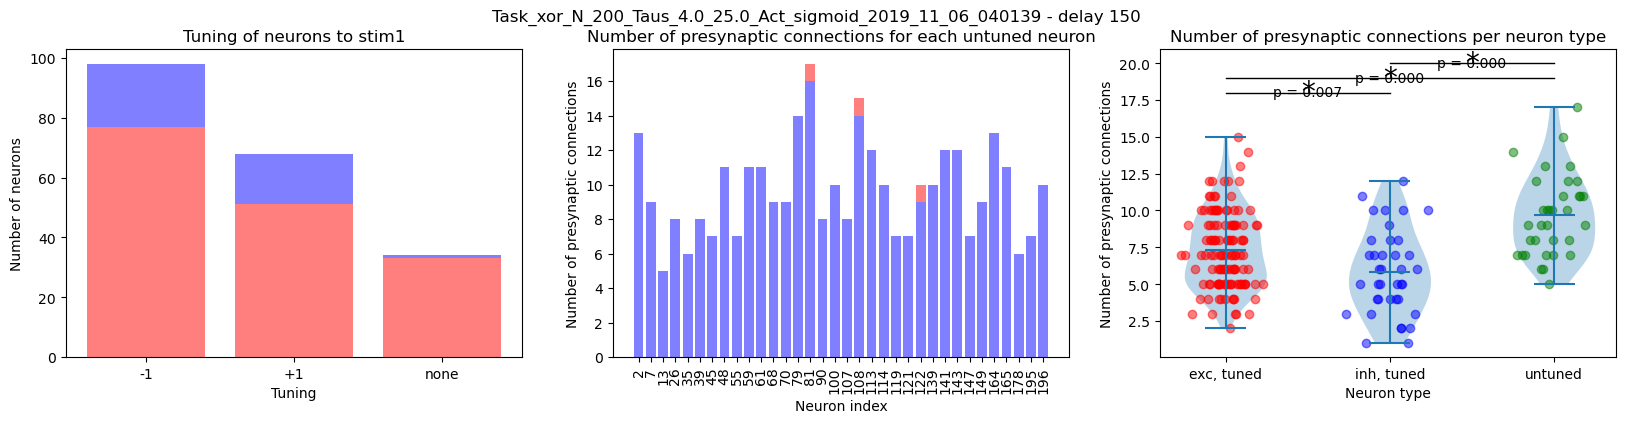

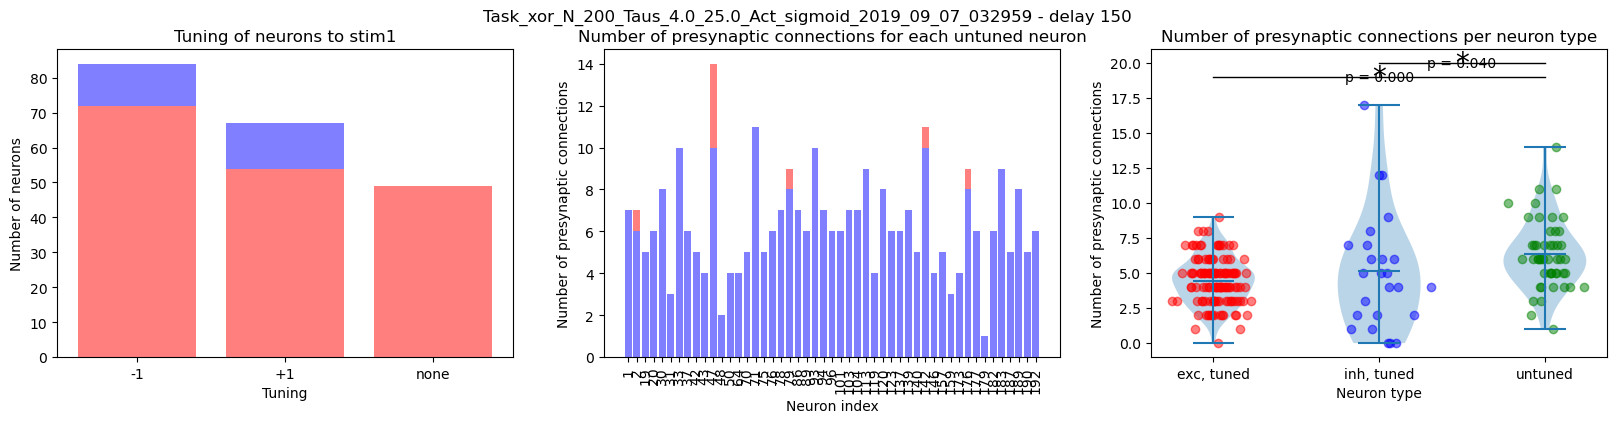

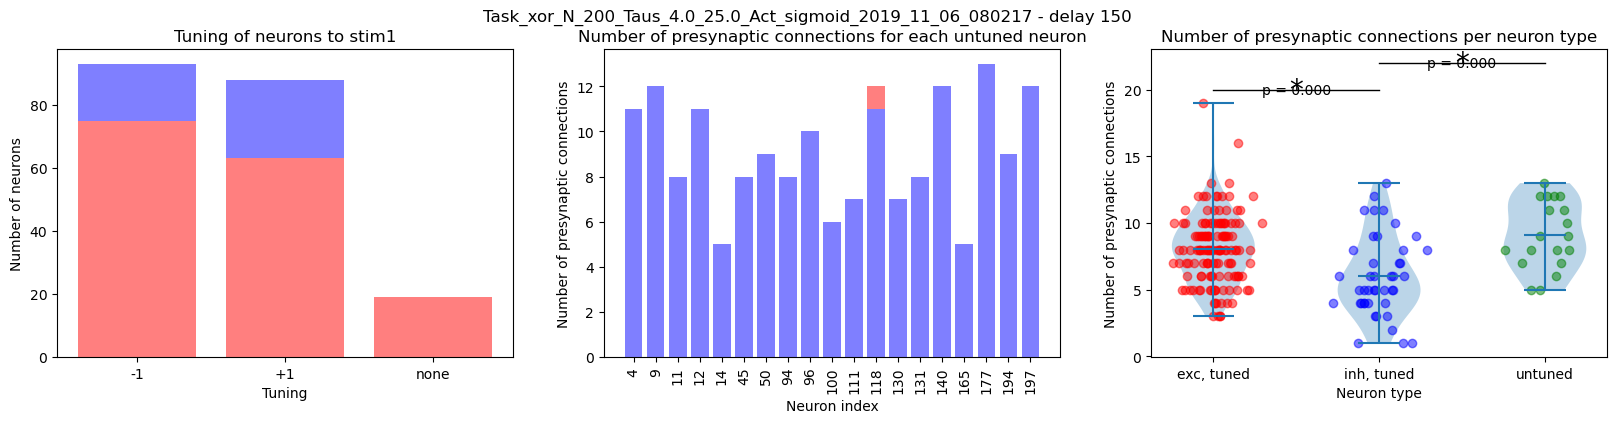

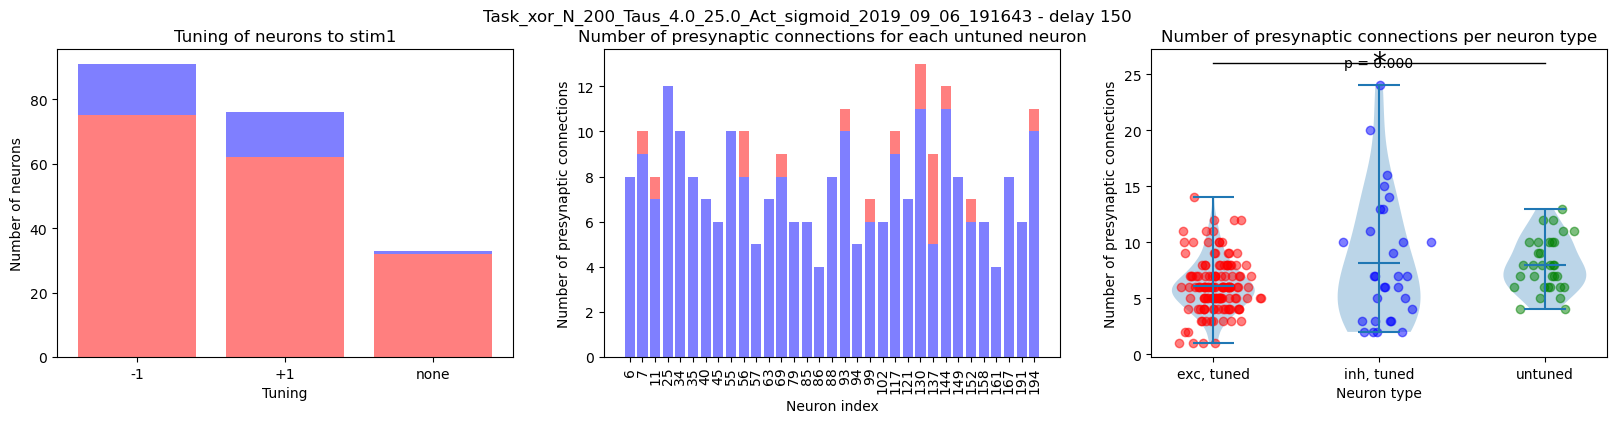

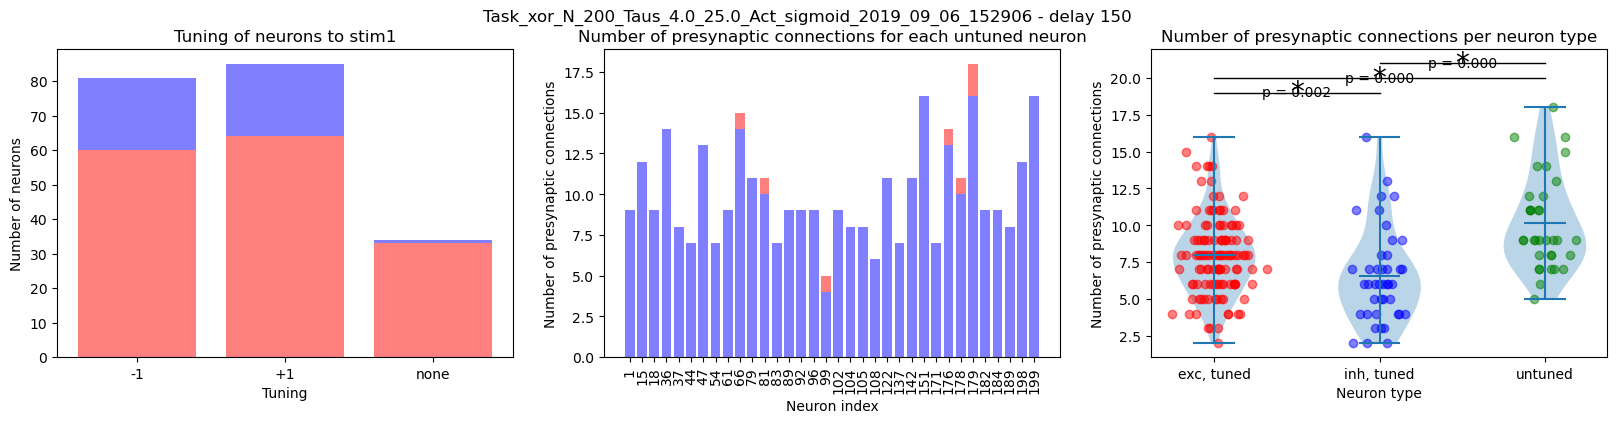

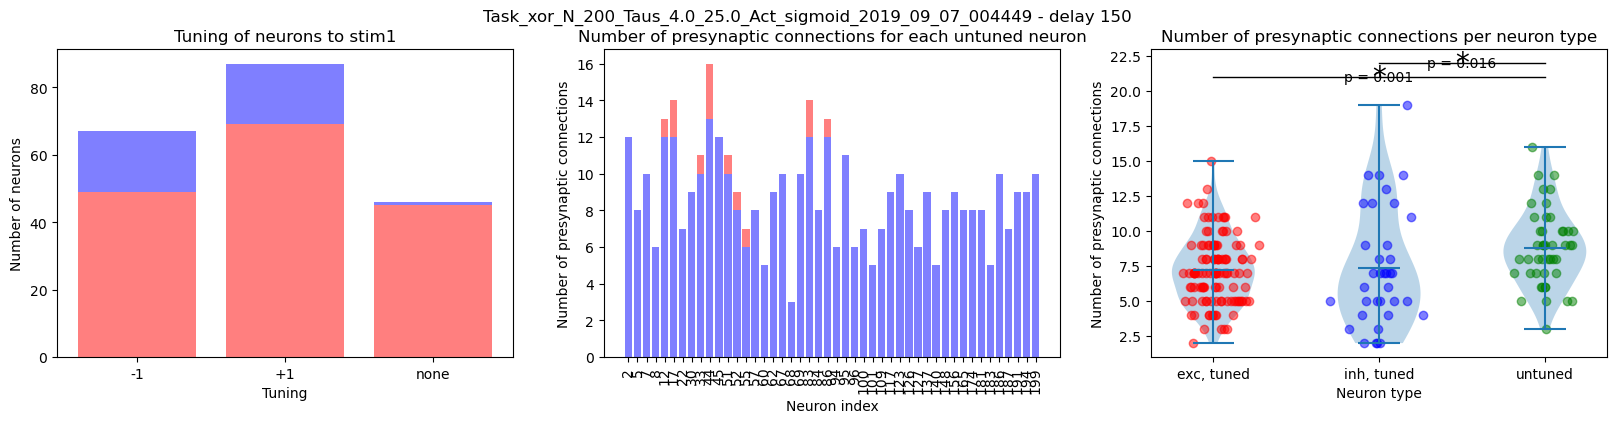

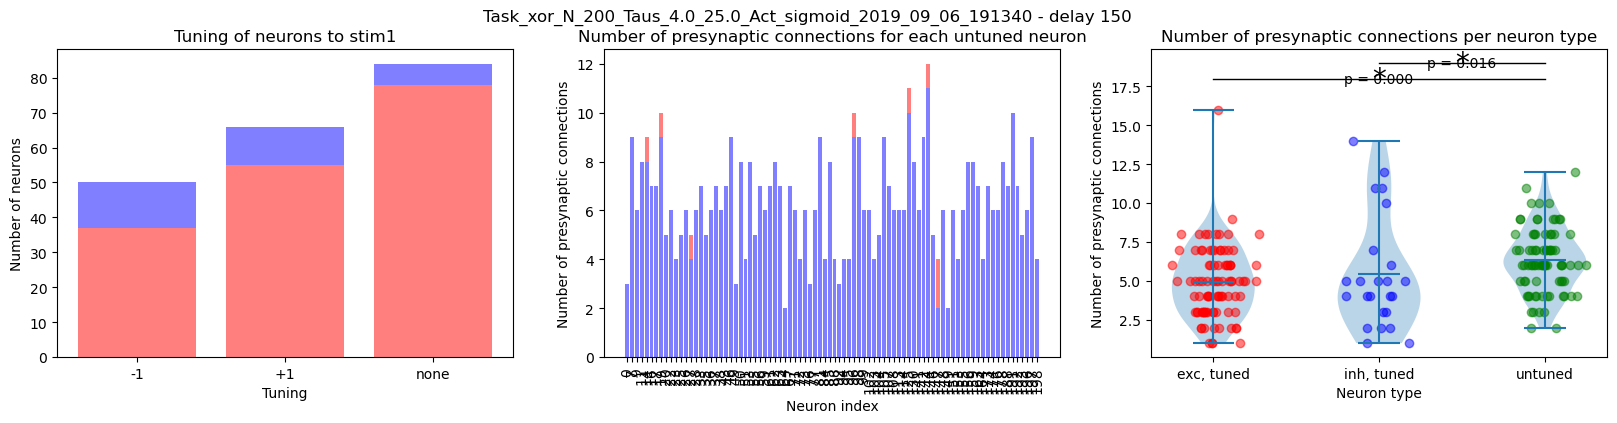

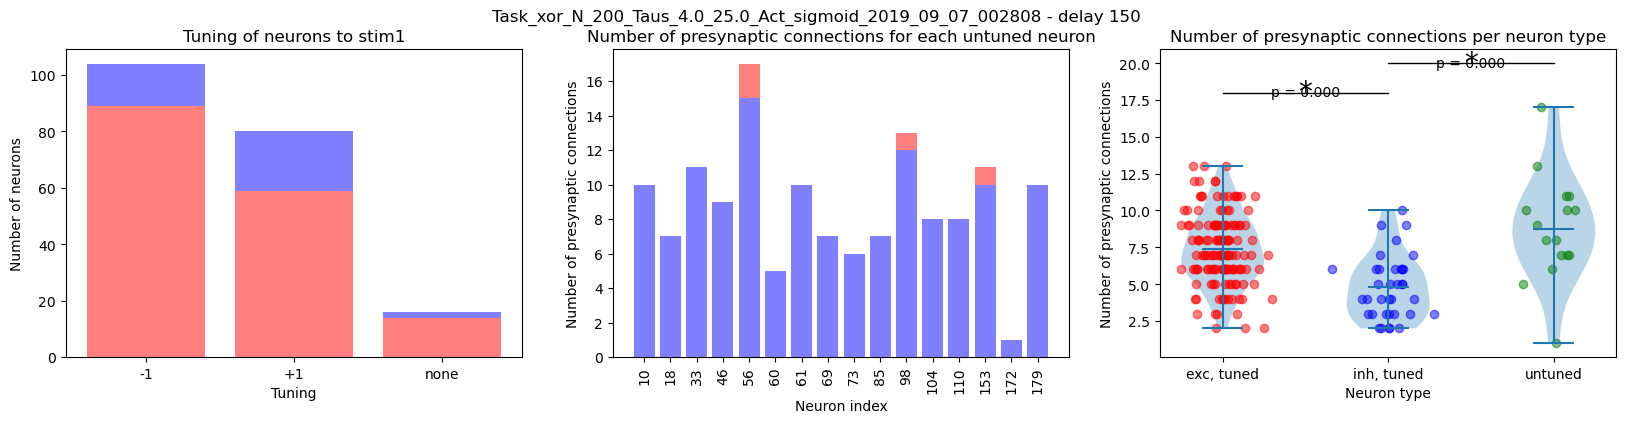

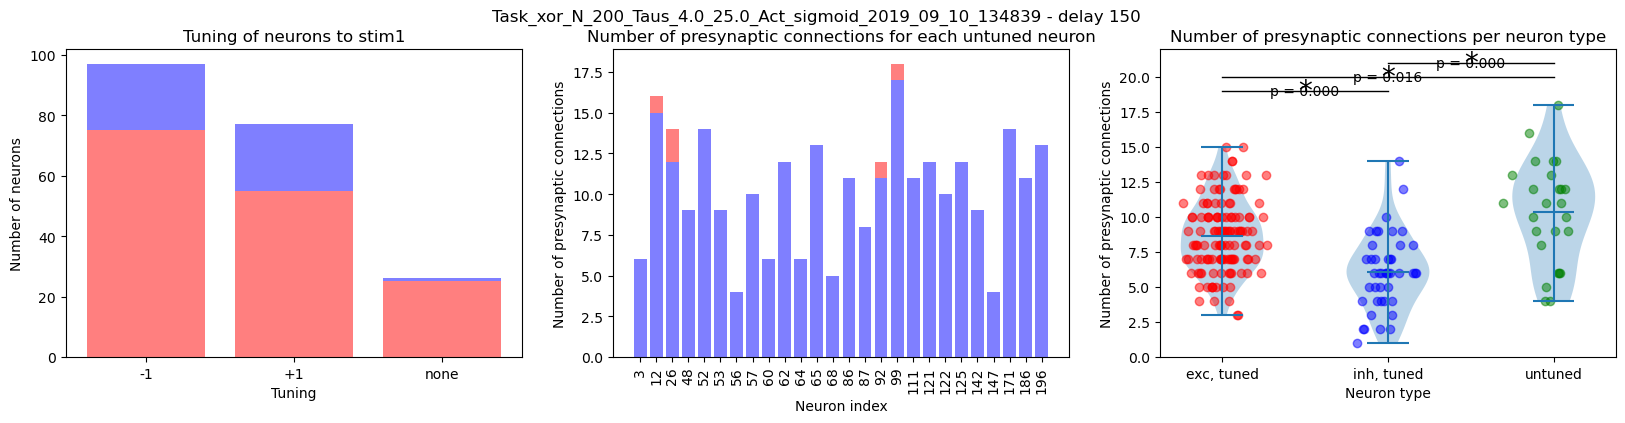

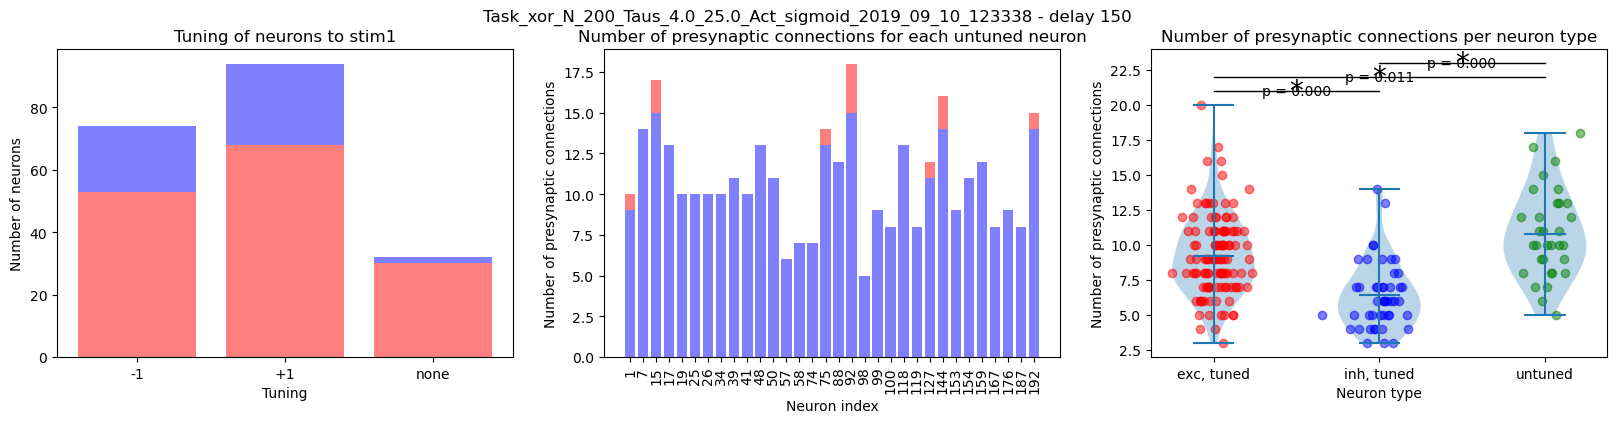

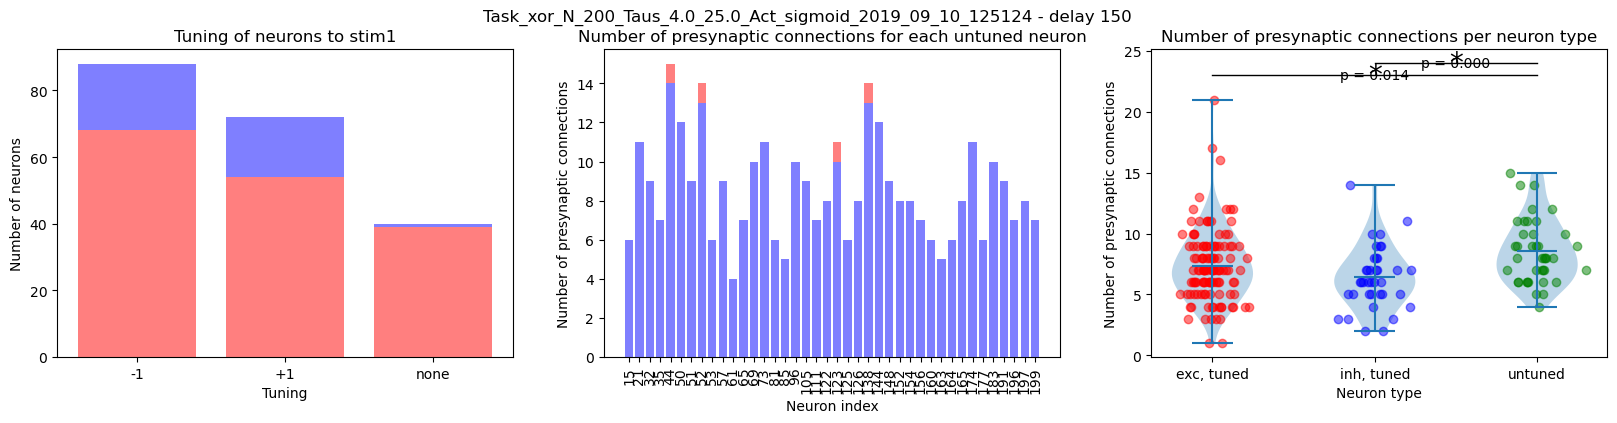

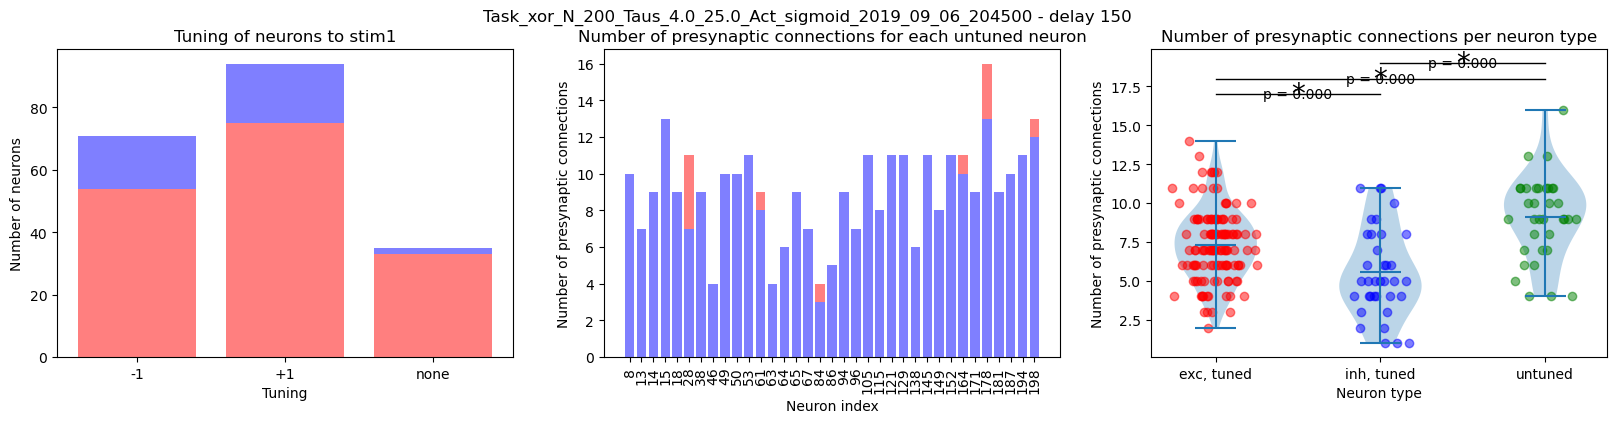

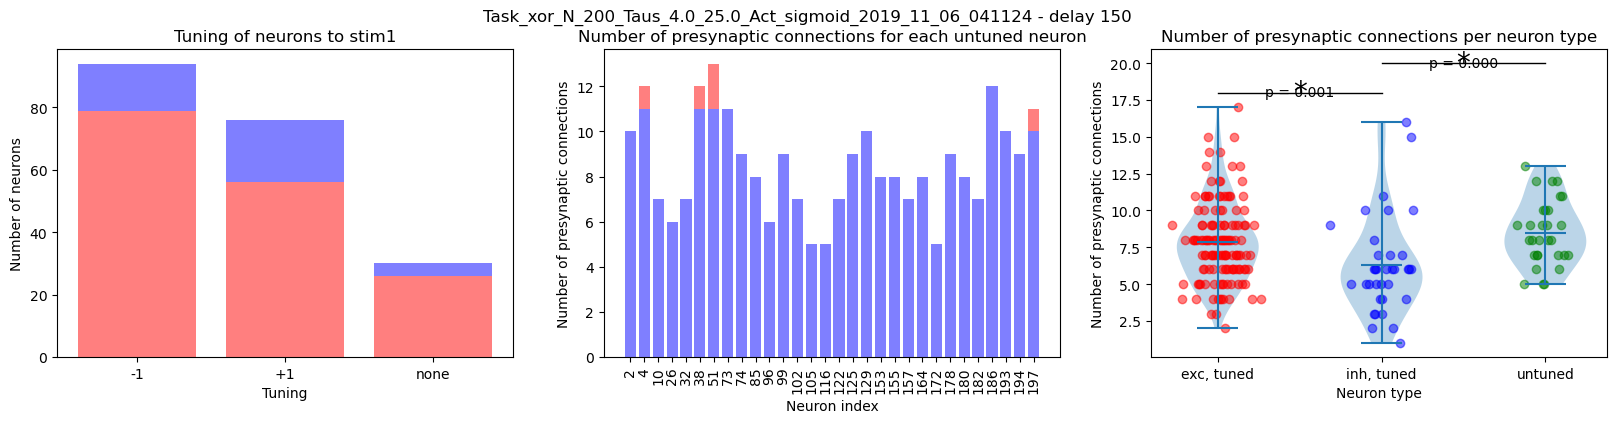

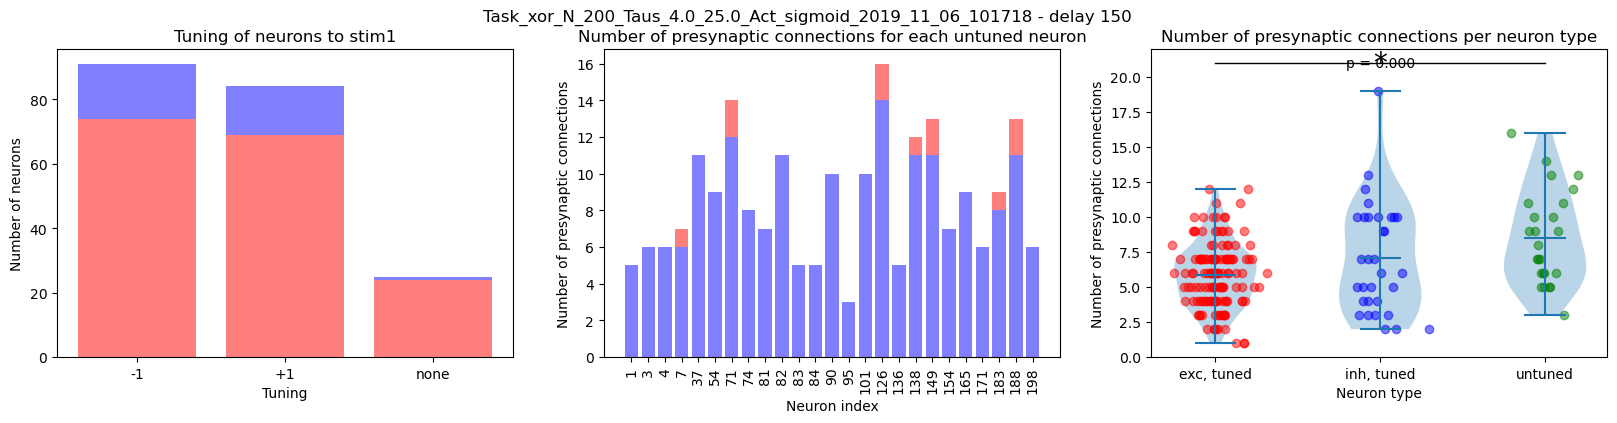

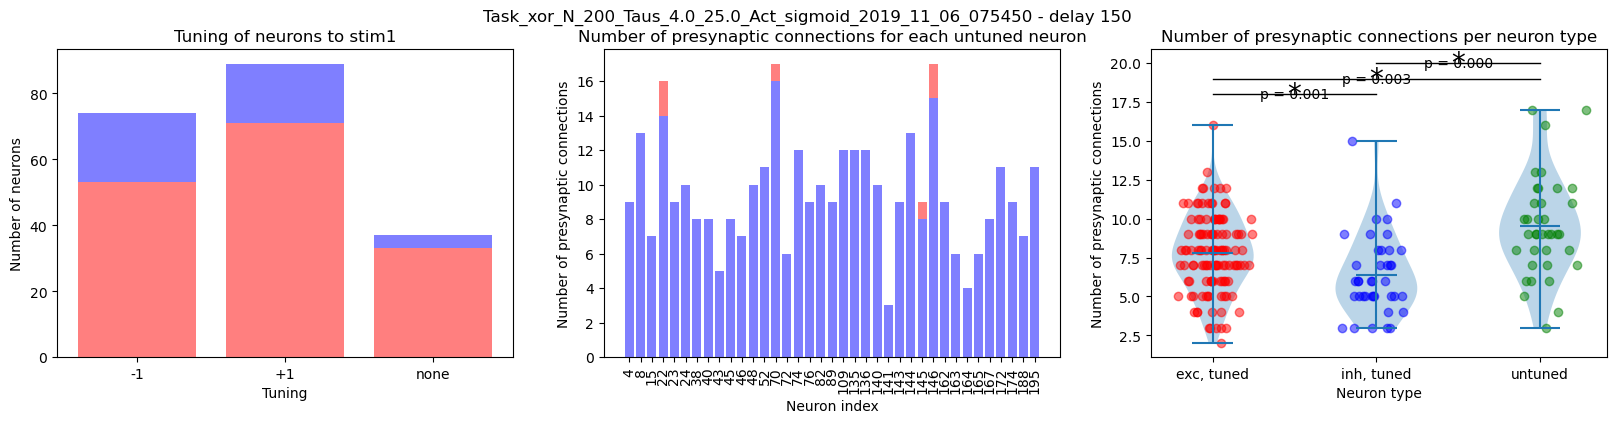

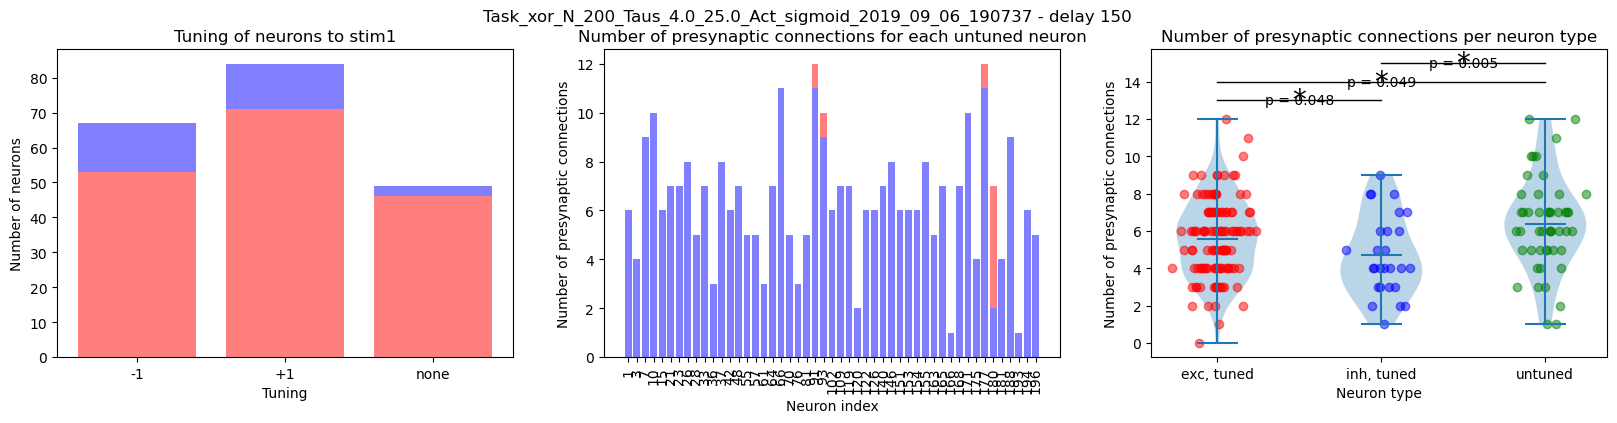

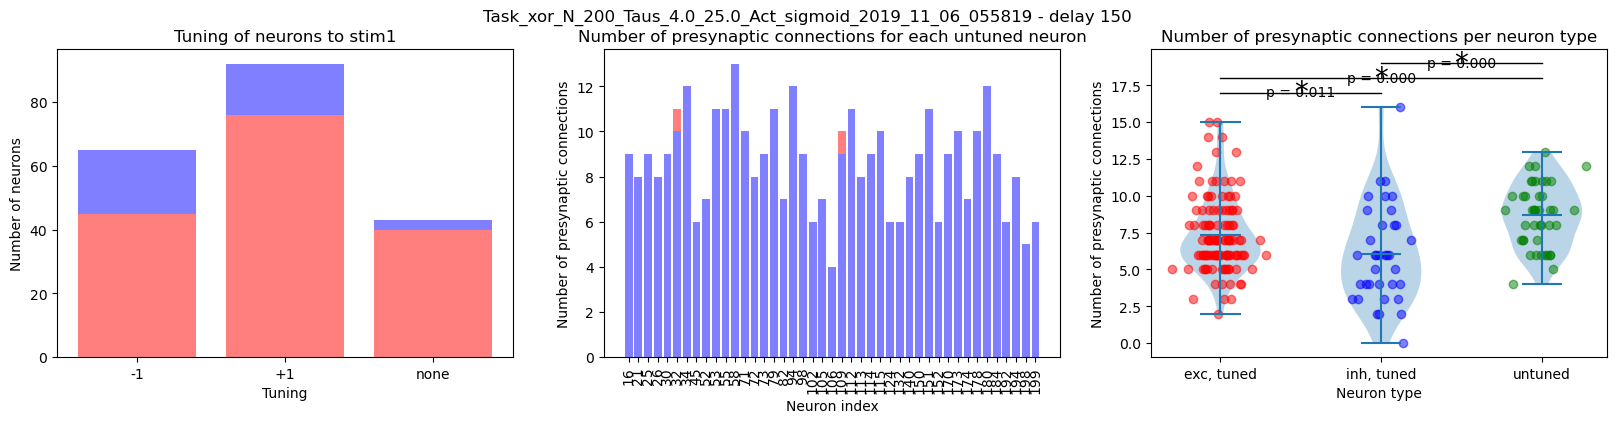

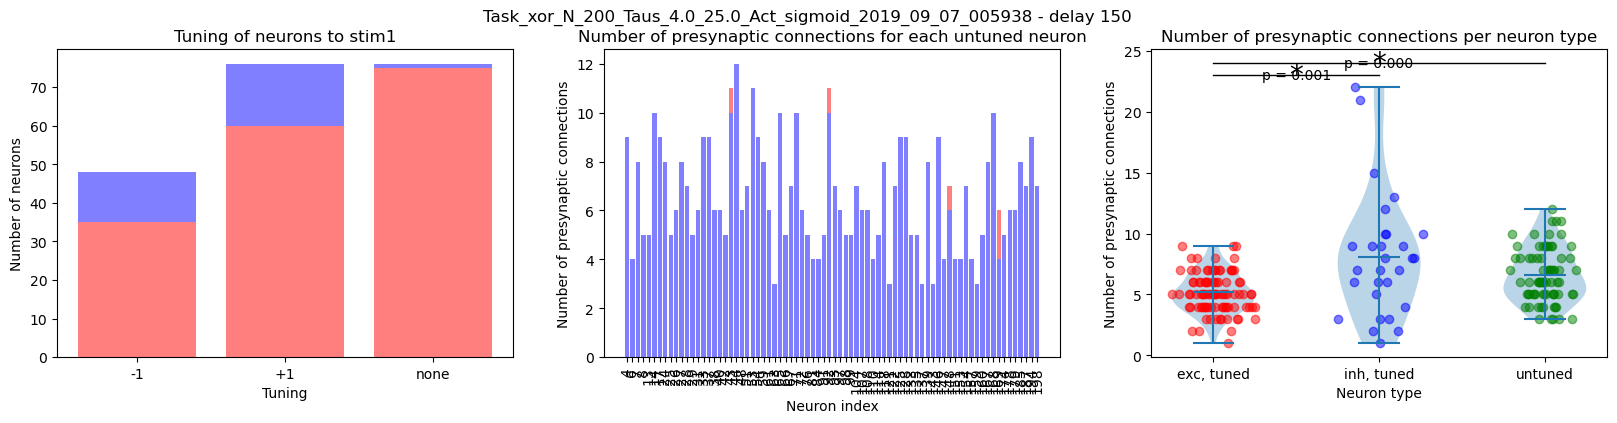

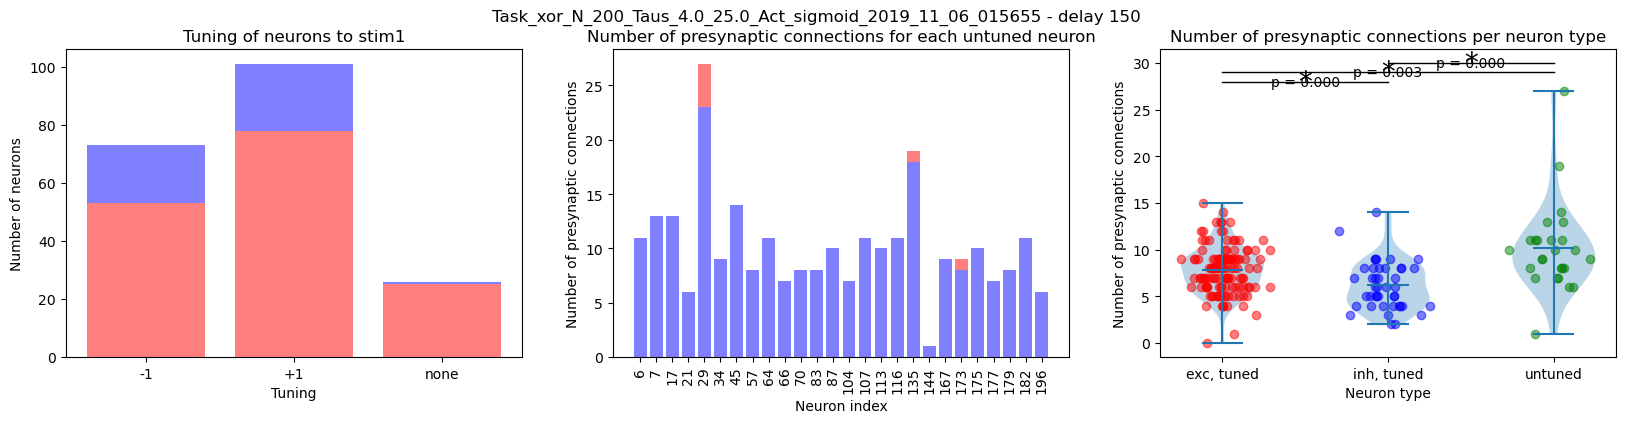

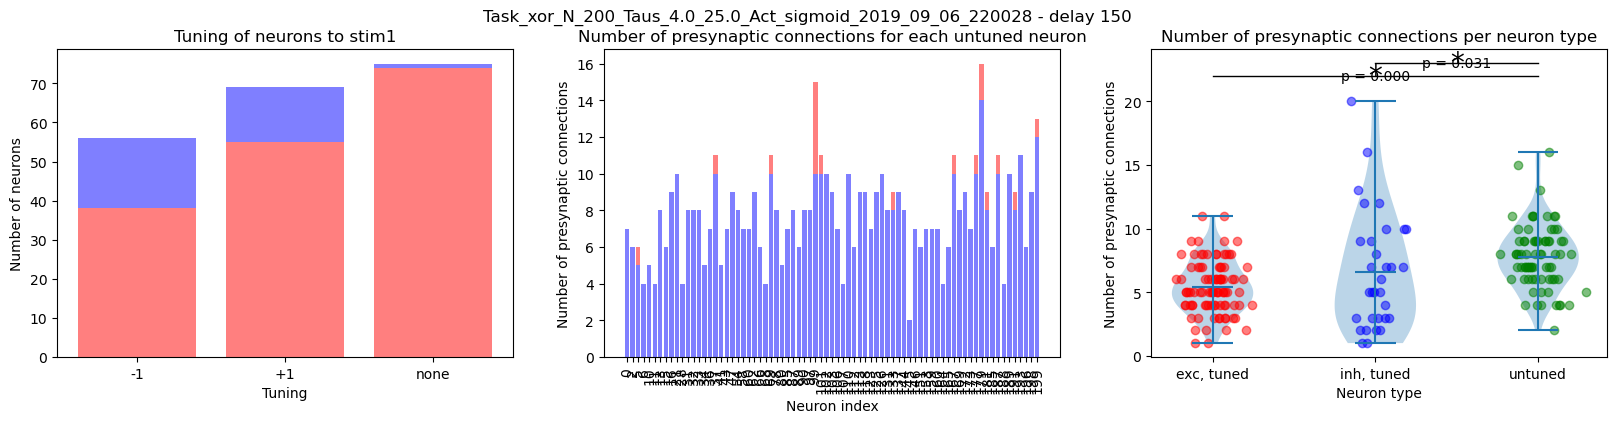

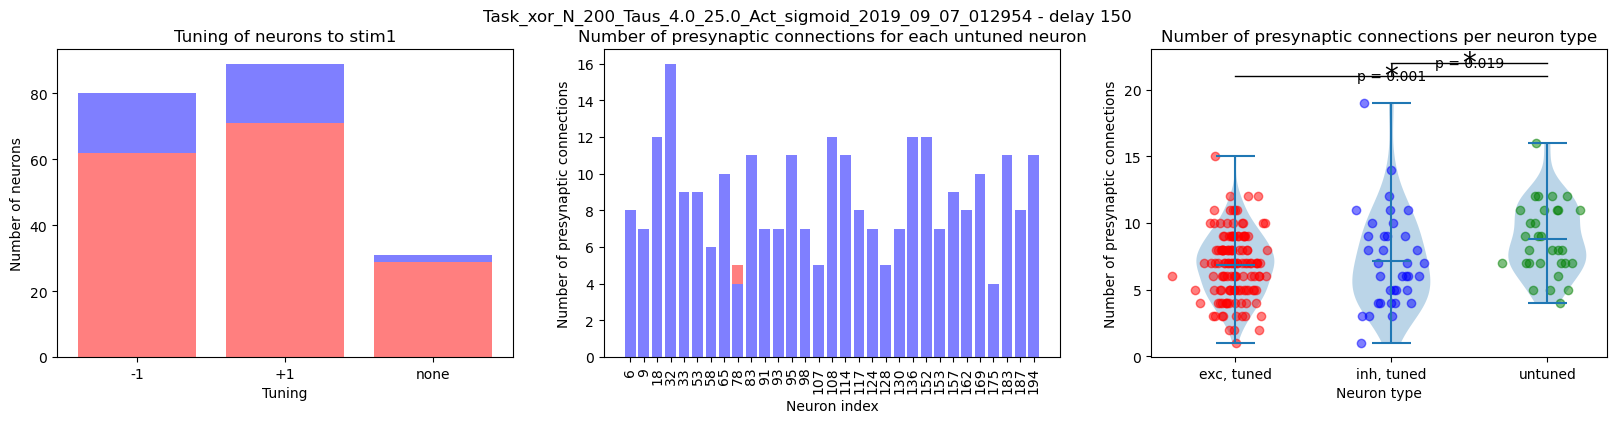

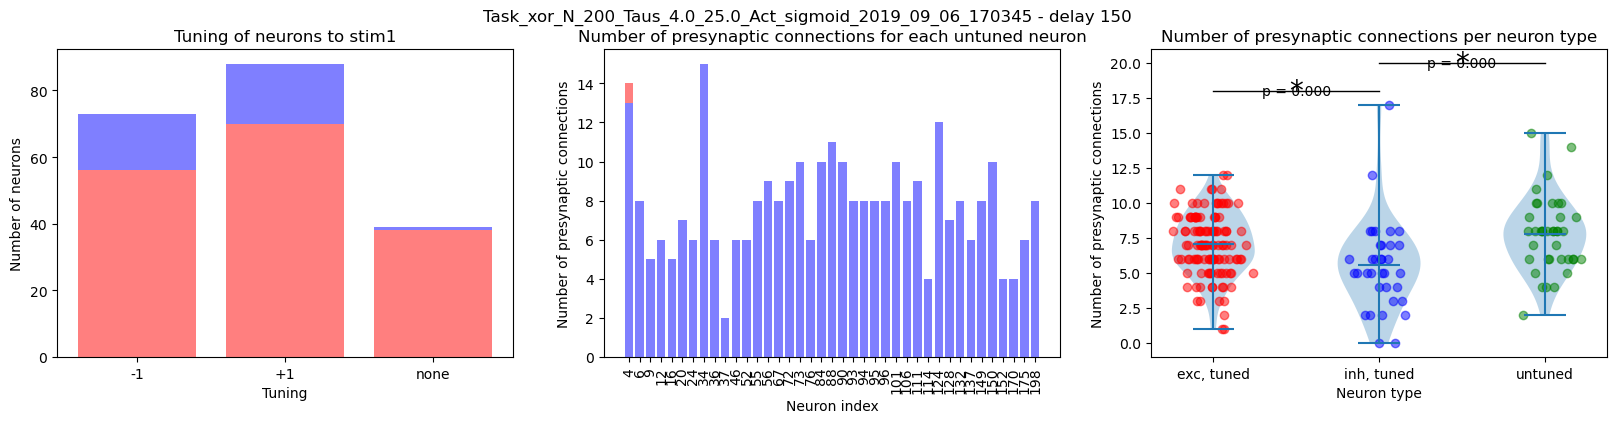

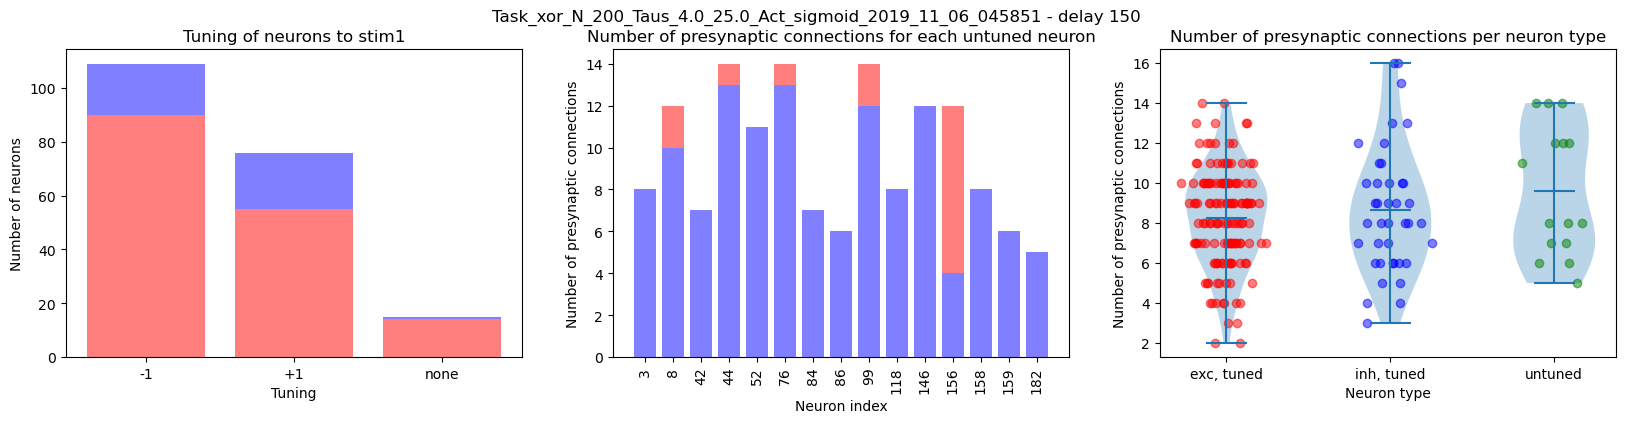

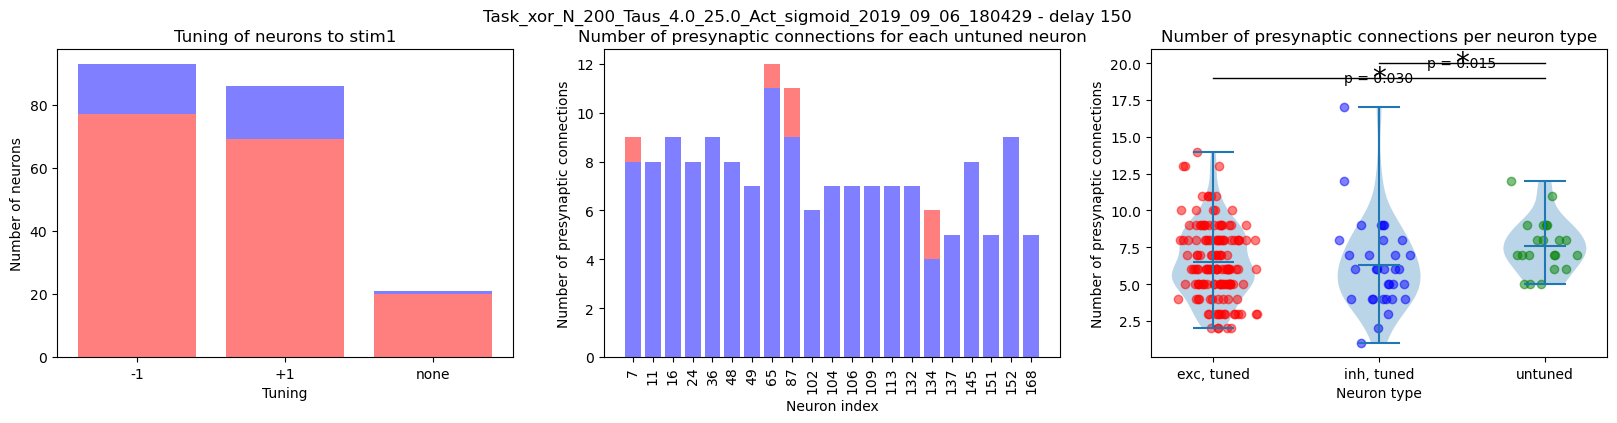

In [18]:
importlib.reload(sn)

mean_num_presyn = np.zeros(len(bad_models))
for i_model, model_name in enumerate(bad_models):
    fig, axs = plt.subplots(1,3, figsize=(20,4))

    # load data
    _, _, rates_data = ld.load_neural_data(model_name, condn_phrase, condn_num,
                                                  load_LFP=False, load_spikes=False, load_rates=True)
    # behavioral data
    trial_labels, trial_perfs = ld.load_bhv_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)

    # timing data
    _, times_real, fs_dict = ld.load_timing_data(model_name, condn_phrase=condn_phrase, condn_num=condn_num)
    times_ms, _,_ = ld.get_times_dict('ds', condn_phrase, condn_num, model_name)

    # get tuning
    tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    untuned_idxs = np.where(np.isnan(tuning))[0]

    sn.plot_stim1_tuning(tuning, ax=axs[0], exc_ind=exc_ind) # subplot 1

    # check the connectivity of the untuned neurons
    connectivity_df = ld.get_connectivity_df(model_name)
    # get the presynaptic connectivity of the untuned neurons
    untuned_connectivity = connectivity_df[connectivity_df['postsyn_id'].isin(untuned_idxs)]
    untuned_connectivity = untuned_connectivity.sort_values(by='postsyn_id')

    plot_presyn_connections(axs[1], untuned_connectivity, untuned_idxs) # subplot 2

    # get the number of presynaptic connections per neuron for each category
    plot_violin_presynaptic(axs[2], untuned_connectivity, untuned_idxs, exc_ind, inh_ind)

    plt.suptitle(f'{model_name} - {condn_phrase} {condn_num}')

    # save mean
    mean_num_presyn[i_model] = np.mean(untuned_connectivity['postsyn_id'].value_counts())

    plt.show()

In [19]:
mean_num_presyn_untuned = np.zeros(len(bad_models))
mean_num_presyn_tuned_exc = np.zeros(len(bad_models))
mean_num_presyn_tuned_inh = np.zeros(len(bad_models))
mean_num_presyn_all = np.zeros(len(bad_models))
for i_model, model_name in enumerate(bad_models):
    # get tuning
    tuning = sn.calc_stim1_tuning(model_name, condn_phrase, condn_num)
    exc_ind, inh_ind = ld.get_celltype_label(model_name)
    untuned_idxs = np.where(np.isnan(tuning))[0]

    sn.plot_stim1_tuning(tuning, ax=axs[0], exc_ind=exc_ind) # subplot 1

    # check the connectivity of the untuned neurons
    connectivity_df = ld.get_connectivity_df(model_name)

    exc_num_presyn = get_num_presyn(connectivity_df, exc_ind)
    exc_ind_tuned = np.setdiff1d(exc_ind, untuned_idxs) # exclude the exc neurons that are also untuned
    exc_tuned_num_presyn = get_num_presyn(connectivity_df, exc_ind_tuned) # exclude the exc neurons that are also untuned
    inh_num_presyn = get_num_presyn(connectivity_df, inh_ind)
    inh_ind_tuned = np.setdiff1d(inh_ind, untuned_idxs) # exclude the inh neurons that are also untuned
    inh_tuned_num_presyn = get_num_presyn(connectivity_df, inh_ind_tuned) # exclude the inh neurons that are also untuned
    # get the number of presynaptic connections per neuron for the untuned neurons
    untuned_num_presyn = get_num_presyn(connectivity_df, untuned_idxs)
    # get the number of presynaptic connections per neuron for all neurons
    all_num_presyn = get_num_presyn(connectivity_df, np.arange(0, len(exc_ind) + len(inh_ind)))

    mean_num_presyn_untuned[i_model] = np.mean(untuned_num_presyn)
    mean_num_presyn_tuned_exc[i_model] = np.mean(exc_tuned_num_presyn)
    mean_num_presyn_tuned_inh[i_model] = np.mean(inh_tuned_num_presyn)
    mean_num_presyn_all[i_model] = np.mean(all_num_presyn)


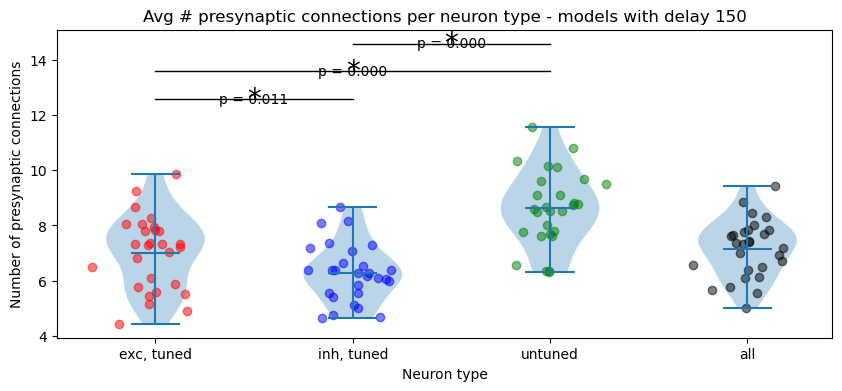

In [24]:
# plot as violinplots

fig, ax = plt.subplots(1,1, figsize=(10,4))

ax.violinplot([mean_num_presyn_tuned_exc, mean_num_presyn_tuned_inh, mean_num_presyn_untuned, mean_num_presyn_all], showmeans=True)
# plot scatter points
ax.scatter(np.random.normal(1, 0.1, size=len(mean_num_presyn_tuned_exc)), mean_num_presyn_tuned_exc, color='r', alpha=0.5)
ax.scatter(np.random.normal(2, 0.1, size=len(mean_num_presyn_tuned_inh)), mean_num_presyn_tuned_inh, color='b', alpha=0.5) 
ax.scatter(np.random.normal(3, 0.1, size=len(mean_num_presyn_untuned)), mean_num_presyn_untuned, color='g', alpha=0.5)
ax.scatter(np.random.normal(4, 0.1, size=len(mean_num_presyn_all)), mean_num_presyn_all, color='k', alpha=0.5)
ax.set_ylabel('Number of presynaptic connections')
ax.set_xlabel('Neuron type')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['exc, tuned', 'inh, tuned', 'untuned', 'all'])

# stats on this
exc_inh_tuned_p = scipy.stats.wilcoxon(mean_num_presyn_tuned_exc, mean_num_presyn_tuned_inh, alternative='two-sided')[1]
exc_untuned_p = scipy.stats.wilcoxon(mean_num_presyn_tuned_exc, mean_num_presyn_untuned, alternative='two-sided')[1]
inh_untuned_p = scipy.stats.wilcoxon(mean_num_presyn_tuned_inh, mean_num_presyn_untuned, alternative='two-sided')[1]

# plot * and p-value for p < 0.05
max_val = np.amax(mean_num_presyn_untuned)
if exc_inh_tuned_p < 0.05:
    ax.text(1.5, max_val+1, '*', fontsize=20, ha='center', va='center')
    ax.text(1.5, max_val+1, f'p = {exc_inh_tuned_p:.3f}', fontsize=10, ha='center', va='center')
    ax.plot([1, 2], [max_val+1, max_val+1], color='k', lw=1)
if exc_untuned_p < 0.05:
    ax.text(2, max_val+2, '*', fontsize=20, ha='center', va='center')
    ax.text(2, max_val+2, f'p = {exc_untuned_p:.3f}', fontsize=10, ha='center', va='center')
    ax.plot([1, 3], [max_val+2, max_val+2], color='k', lw=1)
if inh_untuned_p < 0.05:
    ax.text(2.5, max_val+3, '*', fontsize=20, ha='center', va='center')
    ax.text(2.5, max_val+3, f'p = {inh_untuned_p:.3f}', fontsize=10, ha='center', va='center')
    ax.plot([2, 3], [max_val+3, max_val+3], color='k', lw=1)
plt.title(f'Avg # presynaptic connections per neuron type - models with {condn_phrase} {condn_num}')
plt.show()
